# 13 — Solving Inequalities

**Equations and Inequalities ▸ 5.** An **equation** asks *where two things are equal* — the
answer is usually a few isolated points. An **inequality** asks *where one thing is bigger
(or smaller) than another* — the answer is usually a whole **region** of the number line: a
range, or a union of ranges.

Mental picture: solving $x^2 - x - 6 > 0$ is like asking *"for which $x$ is the parabola
**above** the ground?"* The answer is not points but **intervals**. The main new skill is
the **sign chart** (also called a sign line): find the **boundary points** where an
expression is zero or undefined, and check the sign of the expression in each interval
between them.

**Why it matters for AI.** Almost every real optimisation problem has **constraints**, and
constraints are inequalities: a budget $\le B$, a probability in $[0,1]$, weights inside an
$L^2$ ball $\|w\|\le r$. The **feasible region** — the set of points that satisfy all the
inequalities — is exactly what we search over when we train with constraints. The famous
**ReLU** activation, $\operatorname{ReLU}(x)=\max(0,x)$, is defined by *which side of the
inequality $x>0$ you are on*. And the "margin" in a support-vector machine is a set of
linear inequalities. Learning to describe regions with inequalities is a core skill.

## Quick recall (spaced repetition)
From session 12 (Radical / Quadratic-in-Form Equations). Solutions at the **end of §1**.

1. Solve $\sqrt{x+2} = x$ and say which candidate is **extraneous** and why.
2. Solve $x^4 - 5x^2 + 4 = 0$ by a substitution — state your $u=g(x)$.
3. **(older)** Solve $x^2 + 2x + 5 = 0$ over $\mathbb{C}$.

## What we cover today
1. **Inequalities, solution sets, interval notation** — the language.
2. **Order rules** (add, multiply): the **flip-the-sign** law re-proved; transitivity; the
   **reciprocal** rule.
3. **Linear** and **compound** (and / or) inequalities.
4. **Quadratic & polynomial** inequalities by **sign chart** (justified by Theorem 4).
5. **Rational** inequalities — and the big trap: **do NOT multiply by the denominator**.
6. Python: `sympy` inequality solvers, a hand-built **sign-chart** function, and number-line
   / shaded-region plots of feasible sets (the AI hook).

## 1. Definitions and notation

> **Definition (inequality, solution set).** An **inequality** relates two expressions with
> one of $<,\le,>,\ge$. Its **solution set** is the set of all real $x$ that make the
> statement true. Two inequalities are **equivalent** if they have the same solution set.

> **Definition (interval notation).** We name pieces of the number line:
> - $(a,b)=\{x: a<x<b\}$ — **open** (endpoints excluded).
> - $[a,b]=\{x: a\le x\le b\}$ — **closed** (endpoints included).
> - $[a,b)$, $(a,b]$ — half-open.
> - $(a,\infty)=\{x:x>a\}$, $(-\infty,b]=\{x:x\le b\}$. We **never** put $[$ or $]$ next to
>   $\infty$: infinity is not a number, so it is always excluded with a round bracket.
> - The symbol $\cup$ means **union** ("or", join the pieces); $\cap$ means **intersection**
>   ("and", the overlap). Empty set: $\varnothing$.

```
   solution of  x^2 - x - 6 > 0   is   (-inf, -2) ∪ (3, inf):

     <===========o           o===========>
   ----------------|-----------|----------------  number line
                  -2           3
   ( o = open, endpoint NOT included )
```

> **Definition (boundary / critical point).** For an expression $E(x)$, a **boundary point**
> is a value of $x$ where $E(x)=0$ **or** where $E(x)$ is **undefined** (e.g. a denominator
> is $0$). Between consecutive boundary points the sign of $E$ cannot change — that is the
> whole reason the sign-chart method works (Theorem 4).

## 2. Theorems with full proofs

Recall the **order axioms** of $\mathbb{R}$ (topic 1): there is a set of *positives* $P$ so
that for every real $a$ exactly one of $a\in P$, $a=0$, $-a\in P$ holds (trichotomy), and
$P$ is closed under $+$ and $\times$. We write $a<b$ to mean $b-a\in P$.

### Theorem 1 (rules for manipulating inequalities)
For all real $a,b,c$:
1. **(transitivity)** if $a<b$ and $b<c$ then $a<c$;
2. **(add anything)** if $a<b$ then $a+c<b+c$;
3. **(multiply by positive)** if $a<b$ and $c>0$ then $ac<bc$;
4. **(multiply by negative — FLIP)** if $a<b$ and $c<0$ then $ac>bc$.

**Proof.** Write $x>0$ to mean $x\in P$.
1. $a<b$ and $b<c$ mean $b-a\in P$ and $c-b\in P$. $P$ is closed under addition, so
   $(b-a)+(c-b)=c-a\in P$, i.e. $a<c$.
2. $(b+c)-(a+c)=b-a\in P$, so $a+c<b+c$. (Adding the same $c$ does not change the gap.)
3. $b-a\in P$ and $c\in P$; $P$ is closed under multiplication, so $(b-a)c=bc-ac\in P$,
   i.e. $ac<bc$.
4. $c<0$ means $-c\in P$. Then $(b-a)(-c)=ac-bc\in P$, i.e. $bc<ac$, i.e. $ac>bc$. The
   inequality **reverses**. $\qquad\blacksquare$

Rule 4 is the one everybody forgets: **multiplying or dividing an inequality by a negative
number flips $<$ into $>$.** (Same rule we proved back in topic 2 — here from the axioms.)

### Theorem 2 (reciprocals reverse order for same-sign numbers)
If $0<a<b$ then $\dfrac1b<\dfrac1a$ (both positive). (Bigger positive number $\Rightarrow$
smaller reciprocal.)

**Proof.** Since $a,b>0$, their product $ab>0$, so $\tfrac1{ab}>0$ (a positive number has a
positive reciprocal: if $\tfrac1{ab}$ were negative, multiplying by $ab>0$ would give
$1<0$). From $a<b$, multiply both sides by the positive number $\tfrac1{ab}$ (Theorem 1.3):
$a\cdot\tfrac1{ab}<b\cdot\tfrac1{ab}$, i.e. $\tfrac1b<\tfrac1a$. $\qquad\blacksquare$

> This is exactly **why you must not "cross-multiply" a rational inequality**: multiplying
> by the denominator is multiplying by something whose **sign you do not know**, and by
> Theorem 1.4 the direction might flip. We avoid this by moving everything to one side and
> using a sign chart instead.

### Theorem 3 (sign of a product)
For real numbers, $\ ab>0 \iff (a>0\text{ and }b>0)\text{ or }(a<0\text{ and }b<0)$
(same sign), and $\ ab<0 \iff a,b$ have **opposite** signs. Also $ab=0\iff a=0$ or $b=0$.

**Proof.** Closure of $P$ under $\times$: if $a,b>0$ then $ab>0$. If $a,b<0$ then
$-a,-b\in P$, so $ab=(-a)(-b)\in P$, i.e. $ab>0$. If one is positive and the other negative,
say $a>0,b<0$: then $a\in P$, $-b\in P$, so $a(-b)=-ab\in P$, i.e. $ab<0$. The three cases
(and the zero case, from the Zero Product Property, topic 5) are exhaustive by trichotomy,
which also gives the converses. $\qquad\blacksquare$

**Corollary (product of several factors).** The sign of a product
$(x-r_1)(x-r_2)\cdots(x-r_k)$ is determined by **how many** factors are negative: an **even**
number of negative factors $\Rightarrow$ product $>0$; an **odd** number $\Rightarrow$
product $<0$. This is what makes a sign chart work.

### Theorem 4 (an expression keeps one sign between consecutive boundary points)
Let $E(x)$ be a product/quotient of linear factors (and possibly irreducible quadratics).
List all its boundary points (zeros of numerator and denominator) in increasing order,
splitting the line into open intervals. On **each** such interval $E$ has a **constant
sign**, so testing **one** point of the interval reveals the sign on the whole interval.

**Proof (at our level).** On an open interval containing no boundary point, no linear factor
$x-r_j$ changes sign, because $x-r_j$ is negative for $x<r_j$ and positive for $x>r_j$ and
equals $0$ only at the boundary $r_j$, which is excluded. Any irreducible quadratic factor
(discriminant $<0$) has constant sign everywhere (topic 10/11: it is never zero, and it has
the sign of its leading coefficient). By Theorem 3 the sign of the whole product/quotient is
the product of the signs of its factors, and since **no factor** switches sign inside the
interval, neither does $E$. Hence one test point decides the interval. $\qquad\blacksquare$

*(The deep reason is the Intermediate Value Theorem: a continuous function can only change
sign by passing through $0$. We meet that theorem properly when we reach calculus.)*

### Recall-quiz solutions (from the top)
1. Square: $x+2=x^2\Rightarrow x^2-x-2=(x-2)(x+1)=0$, candidates $2,-1$. Check original:
   $x=2$ gives $\sqrt4=2$ ✓; $x=-1$ gives $\sqrt1=1\ne-1$ ✗ — **extraneous** (squaring lost
   the sign). Answer $x=2$.
2. $u=x^2$: $u^2-5u+4=(u-1)(u-4)=0\Rightarrow u=1,4\Rightarrow x=\pm1,\pm2$.
3. $x=\dfrac{-2\pm\sqrt{-16}}{2}=-1\pm2i$.

## 3. Worked examples

**Example A — linear (watch the flip).** Solve $-3x + 2 \le 11$.
Subtract $2$: $-3x \le 9$. Divide by $-3$ **and flip** (Theorem 1.4): $x \ge -3$.
Solution: $[-3,\infty)$.

**Example B — compound "and".** Solve $-1 < 2x+3 \le 7$.
Subtract $3$ from all three parts: $-4 < 2x \le 4$. Divide by $2$ (positive, no flip):
$-2 < x \le 2$. Solution: $(-2,2]$.

**Example C — compound "or".** Solve $2x-1<-5$ **or** $3x+2\ge 11$.
Left: $x<-2$. Right: $x\ge3$. Union: $(-\infty,-2)\cup[3,\infty)$.

**Example D — quadratic by sign chart.** Solve $x^2 - x - 6 > 0$.
Factor: $(x-3)(x+2) > 0$. Boundary points $-2,\,3$ split the line into three intervals.
Test one point in each:

| interval | test $x$ | $x+2$ | $x-3$ | product |
|---|---|---|---|---|
| $(-\infty,-2)$ | $-3$ | $-$ | $-$ | $+$ |
| $(-2,3)$ | $0$ | $+$ | $-$ | $-$ |
| $(3,\infty)$ | $4$ | $+$ | $+$ | $+$ |

We want $>0$: the outer intervals. Answer $(-\infty,-2)\cup(3,\infty)$. (Endpoints excluded
because the inequality is strict.)

**Example E — always true / never true.** Solve $x^2 + x + 1 > 0$.
Discriminant $\Delta=1-4=-3<0$ and leading coefficient $>0$, so this parabola never touches
the axis and opens up: it is **positive for every real $x$** (Theorem 4 / topic 11). Solution:
all of $\mathbb{R}=(-\infty,\infty)$. (By contrast $x^2+x+1<0$ has solution $\varnothing$.)

**Example F — polynomial.** Solve $(x-1)(x+2)(x-4) \le 0$.
Boundaries $-2,1,4$. Signs of the product from left to right alternate
$-,+,-,+$ (test $x=-3,0,2,5$). We want $\le 0$: the intervals where it is negative, **plus**
the boundary points (equality allowed). Answer $(-\infty,-2]\cup[1,4]$.

**Example G — rational (the trap).** Solve $\dfrac{x-1}{x+2} \ge 0$.
**Do not** multiply by $x+2$ (unknown sign!). Boundaries: numerator $0$ at $x=1$;
denominator $0$ at $x=-2$ (**excluded**, expression undefined). Sign chart of the quotient
(Theorem 3): $+$ on $(-\infty,-2)$, $-$ on $(-2,1)$, $+$ on $(1,\infty)$. We want $\ge 0$:
$(-\infty,-2)\cup[1,\infty)$. Note $x=1$ **is** included (makes it $0$), but $x=-2$ is
**not** (undefined).

**Example H — rational, move to one side first.** Solve $\dfrac{x+1}{x-3} < 2$.
Subtract: $\dfrac{x+1}{x-3}-2<0\Rightarrow\dfrac{x+1-2(x-3)}{x-3}<0\Rightarrow
\dfrac{-x+7}{x-3}<0\Rightarrow\dfrac{x-7}{x-3}>0$ (multiplied num and denom by $-1$; the
$>$ came from Theorem 1.4). Boundaries $3,7$: answer $(-\infty,3)\cup(7,\infty)$.

## 4. Python demonstrations

`sympy` can solve inequalities exactly and return the solution as intervals. We also build
our **own sign chart** so you can see the method, not just the answer.

In [1]:
import sympy as sp
x = sp.symbols('x', real=True)

# sympy solves inequalities and returns interval/union answers directly.
print("A:", sp.solve_univariate_inequality(-3*x + 2 <= 11, x, relational=False))
print("D:", sp.solve_univariate_inequality(x**2 - x - 6 > 0, x, relational=False))
print("E:", sp.solve_univariate_inequality(x**2 + x + 1 > 0, x, relational=False))
print("F:", sp.solve_univariate_inequality((x-1)*(x+2)*(x-4) <= 0, x, relational=False))
print("G:", sp.solve_univariate_inequality((x-1)/(x+2) >= 0, x, relational=False))
print("H:", sp.solve_univariate_inequality((x+1)/(x-3) < 2, x, relational=False))

A: Interval(-3, oo)
D: Union(Interval.open(-oo, -2), Interval.open(3, oo))
E: Interval(-oo, oo)
F: Union(Interval(-oo, -2), Interval(1, 4))
G: Union(Interval.open(-oo, -2), Interval(1, oo))
H: Union(Interval.open(-oo, 3), Interval.open(7, oo))


In [2]:
# Compound inequalities: 'and' = intersection, 'or' = union.
import sympy as sp
x = sp.symbols('x', real=True)

# B: -1 < 2x+3 <= 7  is the AND of two inequalities.
# reduce_inequalities takes a LIST (all must hold = AND) and returns the combined range.
B = sp.reduce_inequalities([-1 < 2*x + 3, 2*x + 3 <= 7], x)
print("B (and):", B)                       # -2 < x <= 2

# C: (2x-1 < -5) OR (3x+2 >= 11) -> solve each, then UNION the solution sets.
c1 = sp.solveset(2*x - 1 < -5, x, domain=sp.S.Reals)
c2 = sp.solveset(3*x + 2 >= 11, x, domain=sp.S.Reals)
print("C (or) :", sp.Union(c1, c2))         # (-oo, -2) U [3, oo)

B (and): (x <= 2) & (-2 < x)
C (or) : Union(Interval.open(-oo, -2), Interval(3, oo))


In [3]:
# Build our OWN sign chart, exactly the by-hand method of Theorem 4.
import sympy as sp
x = sp.symbols('x', real=True)

def sign_chart(expr):
    """Print the sign of `expr` on each interval between its boundary points
    (zeros of numerator and denominator)."""
    expr = sp.together(expr)                      # combine into one fraction num/den
    num, den = sp.fraction(expr)                  # split numerator and denominator
    # boundary points: real roots of numerator (zeros) and denominator (undefined)
    zeros = sp.solve(num, x)
    undef = sp.solve(den, x)
    pts = sorted(set([p for p in zeros + undef if p.is_real]), key=lambda t: float(t))
    print(f"expr = {expr}")
    print(f"  zeros (=0): {zeros}    undefined (den=0): {undef}")
    # test a point to the left of all, between each pair, and to the right of all
    bounds = [pts[0] - 1] + [ (pts[i]+pts[i+1])/2 for i in range(len(pts)-1) ] + [pts[-1] + 1]
    for t, lab in zip(bounds, ['left'] + ['mid']*(len(pts)-1) + ['right']):
        val = expr.subs(x, t)
        s = '0' if val == 0 else ('+' if val > 0 else '-')
        print(f"  test x = {sp.nsimplify(t)!s:>6}  ->  sign {s}")
    return pts

print("Example D:  x^2 - x - 6")
sign_chart(x**2 - x - 6)
print()
print("Example G:  (x-1)/(x+2)")
sign_chart((x - 1)/(x + 2))

Example D:  x^2 - x - 6
expr = x**2 - x - 6
  zeros (=0): [-2, 3]    undefined (den=0): []
  test x =     -3  ->  sign +
  test x =    1/2  ->  sign -
  test x =      4  ->  sign +

Example G:  (x-1)/(x+2)
expr = (x - 1)/(x + 2)
  zeros (=0): [1]    undefined (den=0): [-2]
  test x =     -3  ->  sign +
  test x =   -1/2  ->  sign -
  test x =      2  ->  sign +


[-2, 1]

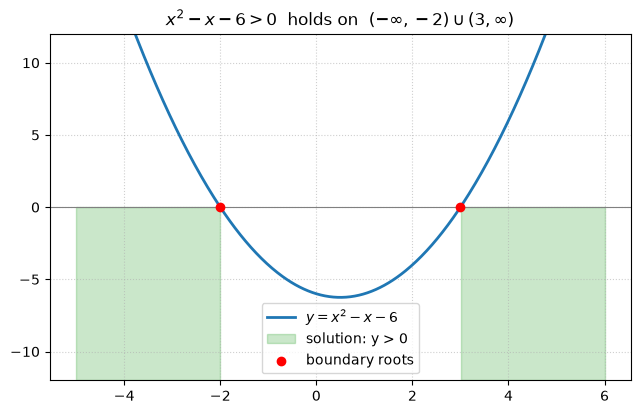

In [4]:
# SEE Example D: shade where the parabola y = x^2 - x - 6 is ABOVE the axis (> 0).
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(-5, 6, 500)
ys = xs**2 - xs - 6
plt.figure(figsize=(7.5, 4.5))
plt.plot(xs, ys, lw=2, label=r'$y = x^2 - x - 6$')
plt.axhline(0, color='gray', lw=0.8)
# fill the x-axis regions where y > 0 (the solution set) in green
plt.fill_between(xs, -12, 0, where=(ys > 0), color='tab:green', alpha=0.25,
                 label='solution: y > 0')
plt.scatter([-2, 3], [0, 0], color='red', zorder=5, label='boundary roots')
plt.ylim(-12, 12); plt.legend(); plt.grid(True, ls=':', alpha=0.6)
plt.title(r'$x^2 - x - 6 > 0$  holds on  $(-\infty,-2)\cup(3,\infty)$')
plt.show()

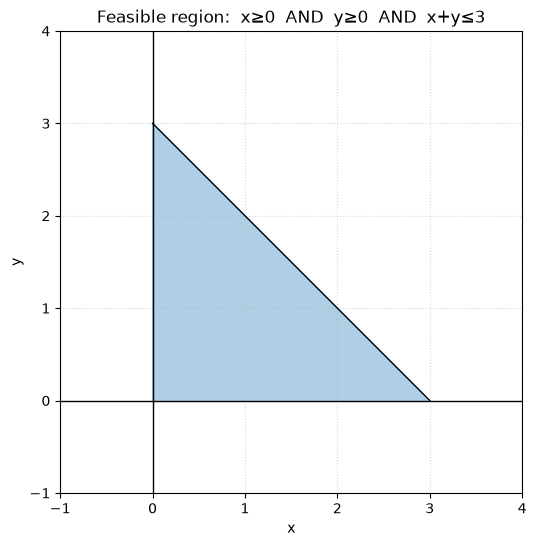

In [5]:
# AI HOOK: a feasible region is an intersection of inequalities.
# Shade the set of points with x >= 0 AND y >= 0 AND x + y <= 3  (a 'budget' triangle),
# the kind of constraint set optimisation searches over.
import numpy as np
import matplotlib.pyplot as plt

g = np.linspace(-1, 4, 400)
X, Y = np.meshgrid(g, g)                       # a grid of (x, y) points
feasible = (X >= 0) & (Y >= 0) & (X + Y <= 3)  # all three inequalities must hold (AND)

plt.figure(figsize=(6, 6))
plt.contourf(X, Y, feasible.astype(int), levels=[0.5, 1.5], colors=['tab:blue'], alpha=0.35)
plt.plot([0, 3], [3, 0], 'k-', lw=1)           # the line x + y = 3 (a boundary)
plt.axhline(0, color='k', lw=1); plt.axvline(0, color='k', lw=1)
plt.xlim(-1, 4); plt.ylim(-1, 4); plt.gca().set_aspect('equal')
plt.title('Feasible region:  x≥0  AND  y≥0  AND  x+y≤3')
plt.xlabel('x'); plt.ylabel('y'); plt.grid(True, ls=':', alpha=0.5)
plt.show()

## 5. Exercises (fill in the cells yourself)

Solve each, give the answer in **interval notation**, and verify with `sympy`. Remember:
**flip** when multiplying/dividing by a negative, and for rationals **move to one side and
use a sign chart** — never cross-multiply. Easy $\to$ hard; last few are proofs.

**Linear & compound**
1. $5x - 3 > 12$.
2. $-2x + 7 \ge 1$  (careful: flip).
3. $\dfrac{x}{3} - 4 < 2$.
4. $-5 \le 3x + 1 < 10$  (compound "and").
5. $x - 4 \le -1$ **or** $2x > 10$  (compound "or").
6. $4(x-1) \ge 2x + 6$.

**Quadratic & polynomial (sign charts)**
7. $x^2 - 4 < 0$.
8. $x^2 - 5x + 6 \ge 0$.
9. $x^2 + 3x + 5 > 0$  (look at $\Delta$ first — topic 11).
10. $2x^2 + x - 3 \le 0$.
11. $x(x-2)(x+3) > 0$.
12. $x^3 \le 4x$  (bring to one side; do **not** divide by $x$).

**Rational**
13. $\dfrac{x-2}{x+1} > 0$.
14. $\dfrac{x+3}{x-2} \le 0$.
15. $\dfrac{1}{x} < 3$  (careful — the sign of $x$ is unknown; move to one side).
16. $\dfrac{2x}{x-1} \ge 1$.

**Proofs / reasoning**
17. **Prove** from the order axioms: if $a<b$ and $c<d$ then $a+c<b+d$ (add two inequalities).
18. **Prove**: if $a<b$ then $-b<-a$ (special case of the flip rule with $c=-1$).
19. **Prove** that $x^2 \ge 0$ for every real $x$, and deduce that $x^2+1>0$ has solution set
    all of $\mathbb{R}$. (Use trichotomy and Theorem 3.)
20. **Explain with a counterexample** why "multiply both sides of $\dfrac{x-1}{x+2}\ge0$ by
    $x+2$" is wrong. Pick an $x<-2$, show cross-multiplying gives the wrong conclusion, and
    state the correct method.

In [6]:
# Exercise 1 — your work here


In [7]:
# Exercise 2 — your work here


In [8]:
# Exercise 3 — your work here


In [9]:
# Exercise 4 — your work here


In [10]:
# Exercise 5 — your work here


In [11]:
# Exercise 6 — your work here


In [12]:
# Exercise 7 — your work here


In [13]:
# Exercise 8 — your work here


In [14]:
# Exercise 9 — your work here


In [15]:
# Exercise 10 — your work here


In [16]:
# Exercise 11 — your work here


In [17]:
# Exercise 12 — your work here


In [18]:
# Exercise 13 — your work here


In [19]:
# Exercise 14 — your work here


In [20]:
# Exercise 15 — your work here


In [21]:
# Exercise 16 — your work here


In [22]:
# Exercise 17 — your work here


In [23]:
# Exercise 18 — your work here


In [24]:
# Exercise 19 — your work here


In [25]:
# Exercise 20 — your work here


## 6. `uv` note — how to run this notebook

Managed with **`uv`**. From the project root (`C:\dev\math`):

- `uv sync` — install dependencies (`numpy`, `sympy`, `matplotlib`, `jupyterlab`).
- `uv run jupyter lab` — open `notebooks/13-solving-inequalities.ipynb`.
- Re-run everything from the terminal (self-test):
  `uv run jupyter nbconvert --to notebook --execute notebooks/13-solving-inequalities.ipynb`.

Restart the kernel and **Run All** to repeat the tutorial. **Two habits to keep:** flip the
sign when you multiply/divide by a negative, and for quadratic/rational inequalities use a
**sign chart** instead of cross-multiplying.